In [1]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
import keras
from tensorflow import keras
from keras import layers
from keras.datasets import mnist
from tensorflow import random
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras import ops
from tensorflow.keras.backend import clear_session
from tensorflow.keras import mixed_precision
from PIL import Image
import json
import requests
import time
import warnings
warnings.filterwarnings('ignore')
os.environ['CUDA_VISIBLE_DEVICES'] = '0'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')
tf.debugging.set_log_device_placement(False)
tf.config.list_logical_devices()

I0000 00:00:1779656195.293791    3534 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1779656195.366773    3534 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1779656195.366819    3534 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1779656195.372830    3534 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1779656195.372979    3534 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

[LogicalDevice(name='/device:CPU:0', device_type='CPU'),
 LogicalDevice(name='/device:GPU:0', device_type='GPU')]

In [2]:
input_shape = (204,146)
input_shape_channels = (204,146,3)

datagen = ImageDataGenerator(
    rescale=1./255,               
    rotation_range=10,                    
    zoom_range=0.1,               
    brightness_range=[0.7, 1.3],       
    fill_mode='nearest'           
)

train_generator = datagen.flow_from_directory(
    'DatasetTFGIngles/',
    target_size=input_shape,  # Ajusta el tamaño de las imágenes
    color_mode= 'rgb',
    batch_size=16,
    class_mode='categorical',
    seed=42,
    save_format= 'jpg'
)

#validation_generator = datagen.flow_from_directory(
#    'DatasetTFGIngles/',
#    target_size=input_shape,
#    color_mode='rgb',
#    batch_size=16,
#    class_mode='categorical',
#    subset='validation',  # Conjunto de validación
#    seed=42,
#    save_format= "jpg"
#) No funciona





Found 104030 images belonging to 104030 classes.


In [3]:
@tf.keras.utils.register_keras_serializable(package='Sampling')
class Sampling(layers.Layer):
    """Uses (z_mean, z_log_var) to sample z, the vector encoding a digit."""

    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self.seed_generator = keras.random.SeedGenerator(1337)

    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch = ops.shape(z_mean)[0]
        dim = ops.shape(z_mean)[1]
        epsilon = keras.random.normal(shape=(batch, dim), seed=self.seed_generator)
        return z_mean + ops.exp(0.5 * z_log_var) * epsilon
        
input_shape = (204, 146, 3)  # Tamaño de las imágenes
latent_dim = 100  # Dimensión del espacio latente

inputs = layers.Input(shape=input_shape)
x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(inputs)
x = layers.BatchNormalization()(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.ZeroPadding2D(((0,0),(0,1)))(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.ZeroPadding2D(((0,1),(0,1)))(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(256, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)
x = layers.ZeroPadding2D(((0,0),(0,1)))(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(512, (3, 3), activation='relu', padding='same')(x)
x = layers.BatchNormalization()(x)

x = layers.Flatten()(x)


z_mean = layers.Dense(latent_dim, name="z_mean")(x)
z_log_var = layers.Dense(latent_dim, name="z_log_var")(x)
z = Sampling()([z_mean, z_log_var])
encoder = keras.Model(inputs, [z_mean, z_log_var, z], name="encoder")
encoder.summary()


decoder_input = layers.Input(shape=(latent_dim,))

x = layers.Dense(13 * 10 * 512, activation='relu')(decoder_input)
x = layers.Reshape((13, 10, 512))(x)

x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(512, (3, 3), activation='relu', padding='same')(x)

x = layers.UpSampling2D((2, 2))(x)
x = layers.Cropping2D(((0,0),(0,1)))(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(256, (3, 3), activation='relu', padding='same')(x)

x = layers.UpSampling2D((2, 2))(x)
x = layers.Cropping2D(((0,1),(0,1)))(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(128, (3, 3), activation='relu', padding='same')(x)

x = layers.UpSampling2D((2, 2))(x)
x = layers.Cropping2D(((0,0),(0,1)))(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(64, (3, 3), activation='relu', padding='same')(x)

x = layers.UpSampling2D((2, 2))(x)
x = layers.BatchNormalization()(x)
x = layers.Conv2DTranspose(32, (3, 3), activation='relu', padding='same')(x)
decoder_output = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
decoder = keras.Model(decoder_input, decoder_output)
decoder.summary()

outputs = decoder(z)


@tf.keras.utils.register_keras_serializable(package='VAE')
class VAE(keras.Model):
    def __init__(self, encoder, decoder, **kwargs):
        super().__init__(**kwargs)
        self.encoder = encoder
        self.decoder = decoder
        self.total_loss_tracker = keras.metrics.Mean(name="total_loss")
        self.reconstruction_loss_tracker = keras.metrics.Mean(
            name="reconstruction_loss"
        )
        self.kl_loss_tracker = keras.metrics.Mean(name="kl_loss")
    
    @property
    def metrics(self):
        return [
            self.total_loss_tracker,
            self.reconstruction_loss_tracker,
            self.kl_loss_tracker,
        ]

    def train_step(self, data):
        with tf.GradientTape() as tape:
            z_mean, z_log_var, z = self.encoder(data[0])
            reconstruction = self.decoder(z)
            data, _ = data
            #data = tf.reshape(data, (16, 204, 146, 3))
            reconstruction_loss = ops.mean(
                ops.sum(
                    keras.losses.binary_crossentropy(data, reconstruction),
                    axis=(1, 2),
                )
            )
            kl_loss = -0.5 * (1 + z_log_var - ops.square(z_mean) - ops.exp(z_log_var))
            kl_loss = ops.mean(ops.sum(kl_loss, axis=1))
            total_loss = reconstruction_loss + kl_loss
        grads = tape.gradient(total_loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(grads, self.trainable_weights))
        self.total_loss_tracker.update_state(total_loss)
        self.reconstruction_loss_tracker.update_state(reconstruction_loss)
        self.kl_loss_tracker.update_state(kl_loss)
        return {
            "loss": self.total_loss_tracker.result(),
            "reconstruction_loss": self.reconstruction_loss_tracker.result(),
            "kl_loss": self.kl_loss_tracker.result(),
        }
    def get_config(self):
        config = super(VAE, self).get_config()
        config.update({
            'encoder': self.encoder,
            'decoder': self.decoder
        })
        return config

    @classmethod
    def from_config(cls, config):
        encoder = config.pop('encoder')
        decoder = config.pop('decoder')
        return cls(encoder, decoder, **config)

vae = VAE(encoder, decoder)
opt = keras.optimizers.Adam()
vae.compile(optimizer=opt)
vae.summary()

Model: "encoder"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 204, 146,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 204, 146,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 204, 146,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 102, 73,   │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 102, 73,   │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 102, 73,   │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 102, 74,   │          0 │ batch_normalizat… │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 51, 37,    │          0 │ zero_padding2d[0… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 51, 37,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 51, 37,    │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 52, 38,    │          0 │ batch_normalizat… │
│ (ZeroPadding2D)     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 26, 19,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 26, 19,    │    295,168 │ max_pooling2d_2[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 26, 19,    │      1,024 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_2    │ (None, 26, 20,    │          0 │ batch_normalizat… │
│ (ZeroPadding2D)     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 13, 10,    │          0 │ zero_padding2d_2… │
│ (MaxPooling2D)      │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 13, 10,    │  1,180,160 │ max_pooling2d_3[

 Total params: 14,884,744 (56.78 MB)

 Trainable params: 14,882,760 (56.77 MB)

 Non-trainable params: 1,984 (7.75 KB)

...

Model: "vae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Functional)            │ [(None, 100), (None,   │    14,884,744 │
│                                 │ 100), (None, 100)]     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ functional (Functional)         │ (None, 204, 146, 3)    │    10,656,323 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,541,067 (97.43 MB)

 Trainable params: 25,536,139 (97.41 MB)

 Non-trainable params: 4,928 (19.25 KB)

In [ ]:
#### clear_session()

policy = mixed_precision.Policy('mixed_float16')
mixed_precision.set_global_policy(policy)

#data = np.concatenate([x_train, x_train], axis=0)
#data = np.expand_dims(data, -1).astype("float16")

vae.fit(
    train_generator,
    epochs=30,
    batch_size = 16
)

In [ ]:
# tf.keras.utils.get_custom_objects()['VAE'] = VAE
vae.save_weights("./Modelos/GPUTrained-30-default-NH.weights.h5",overwrite=True)

In [4]:
vae.load_weights("./Modelos/ModeloGPU.weights.h5",skip_mismatch=False)

tf.Tensor(
[[-0.52126515  0.59831315 -1.2973748  -2.231305   -0.49395707 -0.08727628
   0.71819323 -0.29439765 -1.7703907   0.37603393 -1.35699    -1.9598095
  -0.94919944  0.23102525  1.7424196  -0.4137113  -0.45957488 -0.7553711
   1.2616992   0.30930424  0.9355     -0.8249792  -0.33665797 -0.76630974
  -0.40046316  1.1698817  -0.24684575  0.8626188   0.12401316  1.4512987
  -0.13940962 -0.41452342 -0.73824435 -0.9114464   1.1950116   0.76220757
  -0.00501334  0.08729462 -0.6510588  -0.4971177  -0.21017396  0.12196591
   1.1347692   0.00260423 -1.9225693  -0.02589152 -0.46486008  0.06046423
   2.3259585  -0.4899544   0.08551943 -0.92581385  0.69552076  0.55947584
   0.71810025  0.5580156  -0.14068055  1.1463215  -0.02887435 -0.31827527
  -0.5211136  -1.2569361   0.45835394  0.61458015 -0.41208327 -1.5987864
   0.12008637  0.56928587 -1.1879163  -0.01734911  0.9192387   1.4691828
  -0.48162827 -0.39921072 -0.20889178 -0.09627409  2.2059767  -0.25196248
   0.30258054 -0.42322403 -1.377

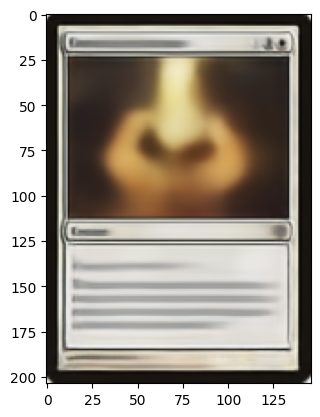

In [8]:
def load_and_preprocess_image(image_path):
    image = Image.open(image_path)
    image = image.resize((146, 204))  
    image = np.array(image)
    image = image.astype('float32') / 255.0  
    image = np.expand_dims(image, axis=0) 
    return image

path = "./DatasetTFGIngles/a74d1bf3-4630-4be0-af5f-590789d27a0c/a74d1bf3-4630-4be0-af5f-590789d27a0c.jpg"

test = load_and_preprocess_image(path)
codes = vae.encoder(test)
img = vae.decoder(codes[2])
img = tf.reshape(img,(204,146,3))
print(codes[2])
plt.imshow(img)

In [19]:
def load_and_preprocess_image(image_path):
    image = Image.open(image_path)
    if image.mode != "RGB":
        image = image.convert("RGB")
    image = image.resize((146, 204))
    image = np.array(image)
    image = image.astype('float32') / 255.0
    image = np.expand_dims(image, axis=0)
    return image

carpeta = './DatasetTFGIngles'
v = []
d = []

i = 0
total = len(os.listdir(carpeta))
for nombre_carpeta in os.listdir(carpeta):
    for nombre_archivo in os.listdir(carpeta + "/" + nombre_carpeta):
        if nombre_archivo.endswith('.jpg'):
            image_path = carpeta + "/" + nombre_carpeta + "/" + nombre_archivo
            test_image = load_and_preprocess_image(image_path)
            i += 1
            per = (i/total)*100
            bar = '#'*int(per/10)
            print(f"\r[{bar.ljust(10)}]% {per}{image_path}#{test_image.shape}",end = '                    ', flush = True)
            codes = vae.encoder(test_image)
            v.append(codes)
            d.append(os.path.splitext(nombre_archivo)[0])

v = np.array(v)
d = np.array(d)
np.save('vectores.npy', v)  
np.save('ids.npy', d)  

[##########]% 100.0./DatasetTFGIngles/ffff0825-9996-4ae5-90c8-cb976ccf4ae0/ffff0825-9996-4ae5-90c8-cb976ccf4ae0.jpg#(1, 204, 146, 3)                                              

In [9]:
def load_and_preprocess_image(image_path):
    image = Image.open(image_path)
    if image.mode != "RGB":
        image = image.convert("RGB")
    image = image.resize((146, 204))
    image = np.array(image)
    image = image.astype('float32') / 255.0
    image = np.expand_dims(image, axis=0)
    return image

def correlacionPearson(tensor1,tensor2):
    mean1 = tf.reduce_mean(tensor1)
    mean2 = tf.reduce_mean(tensor2)
    std1 = tf.math.reduce_std(tensor1)
    std2 = tf.math.reduce_std(tensor2)
    correlacion_pearson = tf.reduce_mean((tensor1 - mean1) * (tensor2 - mean2)) / (std1 * std2)
    return correlacion_pearson.numpy()

vectores = np.load('vectores.npy')
ids = np.load('ids.npy')
names = np.load('nombres.npy')
image_path = "./RealImg/carta2Tratada.jpg"

code = vae.encoder(load_and_preprocess_image(image_path))

#print(code)
print(correlacionPearson(code,vectores[0]))
max=0
total = len(vectores)
for i in range(len(vectores)):
    j = correlacionPearson(code,vectores[i])
    per = (i/total)*100
    bar = '#'*int(per/10)
    print(f"\r[{bar.ljust(10)}] {per}%",end = '                    ', flush = True)
    if max < j:
        max = j
        id = ids[i]
        name = names[i]
print(j)
print(id)
print(id[:36])
print(name)
np.save('idcarta.npy', id[:36]) 

0.82463676
0.8808233# ] 99.99903873882533%                        
dc6c9196-6d28-4cc2-9748-60e9632a502b
dc6c9196-6d28-4cc2-9748-60e9632a502b
The Infamous Cruelclaw


In [10]:
with open("all-cards-20250121102112.json", 'r',encoding="utf8") as jsoncartas:
    jsonstring = jsoncartas.read()
    data = json.loads(jsonstring)
    for i in data:
        if i["id"] == id:
            print(i["name"])

KeyboardInterrupt: 

In [ ]:
import os
from PIL import Image

# Directorio donde están las imágenes
image_dir = './DatasetTFGIngles/'

# Iterar sobre todos los archivos de imagen
for subdir, dirs, files in os.walk(image_dir):
    for file in files:
        file_path = os.path.join(subdir, file)
        try:
            img = Image.open(file_path)  # Intentar abrir la imagen
            img.verify()  # Verificar que la imagen es válida
        except (IOError, SyntaxError) as e:
            print(f"Archivo no válido: {file_path}")


In [6]:
import h5py

# Carga el archivo .h5
with h5py.File('./Modelos/GPUTrainedBuenModelo.weights.h5', 'r') as f:
    # Muestra las claves del archivo
    print(list(f.keys()))


['decoder', 'encoder', 'optimizer', 'vars']


In [10]:
print(len(names))
print(len(ids))

104030
104030


In [14]:
def load_and_preprocess_image(image_path):
    image = Image.open(image_path)
    if image.mode != "RGB":
        image = image.convert("RGB")
    image = image.resize((146, 204))
    image = np.array(image)
    image = image.astype('float32') / 255.0
    image = np.expand_dims(image, axis=0)
    return image

def correlacionPearson(tensor1,tensor2):
    mean1 = tf.reduce_mean(tensor1)
    mean2 = tf.reduce_mean(tensor2)
    std1 = tf.math.reduce_std(tensor1)
    std2 = tf.math.reduce_std(tensor2)
    correlacion_pearson = tf.reduce_mean((tensor1 - mean1) * (tensor2 - mean2)) / (std1 * std2)
    return correlacion_pearson.numpy()

def keyF(e):
    return e["correlacion"]

carpeta = './DatasetTFGIngles'
v = []

img_ref = load_and_preprocess_image("./DatasetTFGIngles/0000a54c-a511-4925-92dc-01b937f9afad/0000a54c-a511-4925-92dc-01b937f9afad.jpg")
ref = vae.encoder(img_ref)

i = 0
total = len(os.listdir(carpeta))
for nombre_carpeta in os.listdir(carpeta):
    for nombre_archivo in os.listdir(carpeta + "/" + nombre_carpeta):
        if nombre_archivo.endswith('.jpg'):
            image_path = carpeta + "/" + nombre_carpeta + "/" + nombre_archivo
            test_image = load_and_preprocess_image(image_path)
            i += 1
            per = (i/total)*100
            bar = '#'*int(per/10)
            print(f"\r[{bar.ljust(10)}]% {per}{image_path}#{test_image.shape}",end = '                    ', flush = True)
            codes = vae.encoder(test_image)
            dicc = {}
            dicc.setdefault("correlacion",correlacionPearson(codes,ref))
            dicc.setdefault("vector",codes)
            dicc.setdefault("id",os.path.splitext(nombre_archivo)[0])
            v.append(dicc)

v.sort(key=keyF)

v = np.array(v)

np.save('dicc.npy', v)  
dicc = np.load('dicc.npy',allow_pickle=True)

[##########]% 100.0./DatasetTFGIngles/ffff0825-9996-4ae5-90c8-cb976ccf4ae0/ffff0825-9996-4ae5-90c8-cb976ccf4ae0.jpg#(1, 204, 146, 3)                                              

In [22]:
import time

def load_and_preprocess_image(image_path):
    image = Image.open(image_path)
    if image.mode != "RGB":
        image = image.convert("RGB")
    image = image.resize((146, 204))
    image = np.array(image)
    image = image.astype('float32') / 255.0
    image = np.expand_dims(image, axis=0)
    return image

def correlacionPearson(tensor1,tensor2):
    mean1 = tf.reduce_mean(tensor1)
    mean2 = tf.reduce_mean(tensor2)
    std1 = tf.math.reduce_std(tensor1)
    std2 = tf.math.reduce_std(tensor2)
    correlacion_pearson = tf.reduce_mean((tensor1 - mean1) * (tensor2 - mean2)) / (std1 * std2)
    return correlacion_pearson.numpy()

def busquedaBinaria(array,ref,profundidad):
    first = 0
    last = len(array)-1
    mid = len(array)/2
    for i in range(profundidad):
        per = (i/profundidad)*100
        bar = '#'*int(per/10)
        print(f"\r[{bar.ljust(10)}] {per}%",end = '                    ', flush = True)
        if array[int(mid)]["correlacion"] >= ref:
            last = int(mid)
            mid = (int(first) + int(mid))/2
        elif array[int(mid)]["correlacion"] < ref:
            first = int(mid)
            mid = (int(last) + int(mid))/2
    print(f"BusquedaBinaria: {last-first} datos de busqueda ({int(first)},{int(last)})")
    return array[int(first):int(last)]

startTime = time.time()

data = np.load('data.npy', allow_pickle=True)

loadTimet = time.time()
loadTime = loadTimet - startTime

image_path = "./RealImg/cartaTratada2.jpg"

code = vae.encoder(load_and_preprocess_image(image_path))

img_ref = load_and_preprocess_image("./DatasetTFGIngles/0000a54c-a511-4925-92dc-01b937f9afad/0000a54c-a511-4925-92dc-01b937f9afad.jpg")
ref = vae.encoder(img_ref)

corrRef = correlacionPearson(code,ref)

vectores = busquedaBinaria(data,corrRef,4) 

binaryTimet = time.time()
binaryTime = binaryTimet - loadTimet

max=0
i = 0
total = len(vectores)
for d in vectores:
    j = correlacionPearson(code,vectores[i]["vector"])
    i += 1
    per = (i/total)*100
    bar = '#'*int(per/10)
    print(f"\r[{bar.ljust(10)}] {per}%",end = '                    ', flush = True)
    if max < j:
        max = j
        id = d["id"]
        name = d["nombre"]
        dicCarta = d
        
searchTimet = time.time()
searchTime = searchTimet - binaryTimet
totalTime = searchTimet - startTime

print("\n")
print(j)
print(id)
print(id[:36])
print(name)
np.save('idcarta.npy', id[:36]) 

print(f"Load: {loadTime}  Binary: {binaryTime}  Search: {searchTime} Total: {totalTime}")

for d in data:
    if d["id"] == "455bd5f0-0f4d-48d3-97d1-5b9320cddca8":
        CC = d["correlacion"]

img_CC = load_and_preprocess_image("./DatasetTFGIngles/455bd5f0-0f4d-48d3-97d1-5b9320cddca8/455bd5f0-0f4d-48d3-97d1-5b9320cddca8.jpg")
CCcode = vae.encoder(img_CC)

CCRC = correlacionPearson(CCcode,ref)

print(f"refcartaTratada: {corrRef}")
print(f"refcartaEncontrada: {dicCarta['correlacion']}")
print(f"refCC: {CC}")
print(f"refCCRC: {CCRC}")

BusquedaBinaria: 6502 datos de busqueda (6501,13003)
[##########] 100.0%                                   

0.4876327
2c275a5f-ec89-4d0c-9183-cd657051fb5c
2c275a5f-ec89-4d0c-9183-cd657051fb5c
Soul of Zendikar
Load: 101.0705714225769  Binary: 0.7114741802215576  Search: 33.77958846092224 Total: 135.5616340637207
refcartaTratada: 0.520264744758606
refcartaEncontrada: 0.5186288952827454
refCC: 0.5571395754814148


In [ ]:
def load_and_preprocess_image(image_path):
    image = Image.open(image_path)
    if image.mode != "RGB":
        image = image.convert("RGB")
    image = image.resize((146, 204))
    image = np.array(image)
    image = image.astype('float32') / 255.0
    image = np.expand_dims(image, axis=0)
    return image

def correlacionPearson(tensor1,tensor2):
    mean1 = tf.reduce_mean(tensor1)
    mean2 = tf.reduce_mean(tensor2)
    std1 = tf.math.reduce_std(tensor1)
    std2 = tf.math.reduce_std(tensor2)
    correlacion_pearson = tf.reduce_mean((tensor1 - mean1) * (tensor2 - mean2)) / (std1 * std2)
    return correlacion_pearson.numpy()



carpeta = './DatasetTFGIngles'
v = []

i = 0
total = len(os.listdir(carpeta))
for nombre_carpeta in os.listdir(carpeta):
    for nombre_archivo in os.listdir(carpeta + "/" + nombre_carpeta):
        if nombre_archivo.endswith('.jpg'):
            image_path = carpeta + "/" + nombre_carpeta + "/" + nombre_archivo
            test_image = load_and_preprocess_image(image_path)
            i += 1
            per = (i/total)*100
            bar = '#'*int(per/10)
            print(f"\r[{bar.ljust(10)}]% {per}{image_path}#{test_image.shape}",end = '                    ', flush = True)
            codes = vae.encoder(test_image)
            dicc = {}
            dicc.setdefault("vector",codes)
            dicc.setdefault("id",os.path.splitext(nombre_archivo)[0])
            v.append(dicc)


v = np.array(v)

np.save('dicc.npy', v)  
dicc = np.load('dicc.npy',allow_pickle=True)

[##########]% 100.0./DatasetTFGIngles/ffff0825-9996-4ae5-90c8-cb976ccf4ae0/ffff0825-9996-4ae5-90c8-cb976ccf4ae0.jpg#(1, 204, 146, 3)                                              

In [ ]:
def search(vectores):
    max=0
    i = 0
    total = len(vectores)
    for d in vectores:
        j = correlacionPearson(code,vectores[i]["vector"])
        i += 1
        per = (i/total)*100
        bar = '#'*int(per/10)
        print(f"\r[{bar.ljust(10)}] {per}%",end = '                    ', flush = True)
        if max < j:
            max = j
            id = d["id"]
            name = d["nombre"]
            dicCarta = d

data = np.load('data.npy', allow_pickle=True)
st
n = int(len(data)/8)
hilo1 = threading.Thread(target=search(data[0:n]))
hilo2 = threading.Thread(target=search(data[n:2*n]))
hilo3 = threading.Thread(target=search(data[2*n:3*n]))
hilo4 = threading.Thread(target=search(data[3*n:4*n]))
hilo5 = threading.Thread(target=search(data[4*n:5*n]))
hilo6 = threading.Thread(target=search(data[5*n:6*n]))
hilo7 = threading.Thread(target=search(data[6*n:7*n]))
hilo8 = threading.Thread(target=search(data[7*n:len(data)]))

hilo1.start()
hilo2.start()
hilo3.start()
hilo4.start()
hilo5.start()
hilo6.start()
hilo7.start()
hilo8.start()

hilo1.join()
hilo2.join()
hilo3.join()
hilo4.join()
hilo5.join()
hilo6.join()
hilo7.join()
hilo8.join()

In [10]:
data = np.load('data.npy', allow_pickle=True)

In [ ]:
import multiprocessing
import time

def load_and_preprocess_image(image_path):
    image = Image.open(image_path)
    if image.mode != "RGB":
        image = image.convert("RGB")
    image = image.resize((146, 204))
    image = np.array(image)
    image = image.astype('float32') / 255.0
    image = np.expand_dims(image, axis=0)
    return image

def correlacionPearson(tensor1,tensor2):
    mean1 = tf.reduce_mean(tensor1)
    mean2 = tf.reduce_mean(tensor2)
    std1 = tf.math.reduce_std(tensor1)
    std2 = tf.math.reduce_std(tensor2)
    correlacion_pearson = tf.reduce_mean((tensor1 - mean1) * (tensor2 - mean2)) / (std1 * std2)
    return correlacion_pearson.numpy()

def search(data, cola ,code):
    max=0
    for d in data:
        j = correlacionPearson(code,d["vector"])
        if max < j:
            max = j
        cola.put(max)

if __name__ == "__main__":
    image_path = "./RealImg/cartaTratada2.jpg"
    code = vae.encoder(load_and_preprocess_image(image_path))
    n=int(len(data)/8)
    cola = multiprocessing.Queue()
    procesos = []
    for i in range(8):
        inicio = i*n
        if i == 7:
            fin = len(data)
        else:
            fin = (i+1)*n
        proceso = multiprocessing.Process(target=search, args=(data[inicio:fin], cola,code))
        procesos.append(proceso)
        proceso.start()

    for proceso in procesos:
        proceso.join()

    # Recoger resultados de la cola
    lista = []
    while not cola.empty():
        lista.append(cola.get())

    array = np.array(lista)

    max=0
    for d in array:
        j = correlacionPearson(code,d["vector"])
        if max < j:
            max = j
            id = d["id"]
            name = d["nombre"]
            dicCarta = d

print(name)

2025-03-17 12:34:25.547957: F external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:155] Failed setting context: CUDA_ERROR_NOT_INITIALIZED: initialization error
2025-03-17 12:34:25.578965: F external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:155] Failed setting context: CUDA_ERROR_NOT_INITIALIZED: initialization error
2025-03-17 12:34:25.610168: F external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:155] Failed setting context: CUDA_ERROR_NOT_INITIALIZED: initialization error
2025-03-17 12:34:25.643527: F external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:155] Failed setting context: CUDA_ERROR_NOT_INITIALIZED: initialization error
2025-03-17 12:34:25.675331: F external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:155] Failed setting context: CUDA_ERROR_NOT_INITIALIZED: initialization error
2025-03-17 12:34:25.707064: F external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:155] Failed setting context: CUDA_ERROR_NOT_INITIALIZED: initialization erro

In [3]:
%run AddNames.py

<class 'numpy.ndarray'>
104030
[          ] 3.8267807363260595%                       

KeyboardInterrupt: 

In [17]:
def load_and_preprocess_image(image_path):
    image = Image.open(image_path)
    image = image.resize((146, 204))  
    image = np.array(image)
    image = image.astype('float32') / 255.0  
    image = np.expand_dims(image, axis=0) 
    return image

path = "./DatasetTFGIngles/a74d1bf3-4630-4be0-af5f-590789d27a0c/a74d1bf3-4630-4be0-af5f-590789d27a0c.jpg"

test = load_and_preprocess_image(path)
      
codes = vae.encoder(test)

print(len(codes))

#print(codes)

3
